In [2]:
from moabb.analysis.results import Results
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery
from utils import print_results_summary

results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                          mean    std  count
pipeline               dataset                                              
CSP + LDA              BrainBot-PaperMethodology-3500ms  0.267  0.061      5
CSP + SVM Grid         BrainBot-PaperMethodology-3500ms  0.266  0.051      5
DLCSPauto + shLDA      BrainBot-PaperMethodology-3500ms  0.257  0.067      5
FgMDM                  BrainBot-PaperMethodology-3500ms  0.360  0.077      5
MDM                    BrainBot-PaperMethodology-3500ms  0.244  0.059      5
TS ElasticNet Grid     BrainBot-PaperMethodology-3500ms  0.384  0.054      5
Tangent Space LR       BrainBot-PaperMethodology-3500ms  0.385  0.069      5
Tangent Space SVM Grid BrainBot-PaperMethodology-3500ms  0.400  0.055      5

Detailed Results by Subject and Dataset:
pipeline                                          CSP + LDA  CSP + SVM Grid  DLCSPauto + shLDA  FgMDM    MDM  TS ElasticNet Grid  Tangent Space LR  Tangent Space SVM Grid


In [3]:
results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                        mean    std  count
pipeline             dataset                                              
Keras_DeepConvNet    BrainBot-PaperMethodology-3500ms  0.259  0.031      5
Keras_EEGITNet       BrainBot-PaperMethodology-3500ms  0.240  0.051      5
Keras_EEGNeX         BrainBot-PaperMethodology-3500ms  0.255  0.022      5
Keras_EEGNet_8_2     BrainBot-PaperMethodology-3500ms  0.311  0.106      5
Keras_ShallowConvNet BrainBot-PaperMethodology-3500ms  0.352  0.128      5

Detailed Results by Subject and Dataset:
pipeline                                          Keras_DeepConvNet  Keras_EEGITNet  Keras_EEGNeX  Keras_EEGNet_8_2  Keras_ShallowConvNet
dataset                          subject session                                                                                         
BrainBot-PaperMethodology-3500ms 1       0                    0.248           0.244         0.260             0.299                 0.298
  

### Notes
AUG Tang SVM Grid pipeline seems to get stuck (executed for 7+ hours for one subject without any visible progress) thus results are not complete

### Analysis

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine results from typical MI pipelines and Tensorflow pipelines
print("Reloading results to ensure we have all data...")
results_mi = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI"
)
df_mi = results_mi.to_dataframe()
df_mi['type'] = 'Standard MI'

results_tf = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)
df_tf = results_tf.to_dataframe()
df_tf['type'] = 'Tensorflow'

# Concatenate
all_results = pd.concat([df_mi, df_tf], ignore_index=True)

# Define Channel Counts / Groups
def categorize_dataset(dataset_name):
    if 'BrainBot' in dataset_name:
        return 'BrainBot (Target)'
    elif '16' in dataset_name:
        return '16 Channels (Low Density)'
    else:
        return '60+ Channels (High Density)'

all_results['Channel Group'] = all_results['dataset'].apply(categorize_dataset)

# Add explicit channel count mapping for clarity in plots
channel_counts = {
    'PhysionetMotorImagery': 64,
    'PhysionetMotorImagery16': 16,
    'Weibo2014': 60,
    'Weibo2014_16': 16, 
    'Weibo2014_64_5-classes': 60,
    'BrainBot': 16
}
all_results['n_channels'] = all_results['dataset'].map(channel_counts).fillna(64) 

print("Combined Data Shape:", all_results.shape)
print("Datasets:", all_results['dataset'].unique())

Reloading results to ensure we have all data...
Combined Data Shape: (65, 12)
Datasets: <StringArray>
['BrainBot-PaperMethodology-3500ms']
Length: 1, dtype: str


=== Top 5 Classifiers on 16-Channel Datasets (Mean Accuracy) ===
                            mean       std  count
pipeline                                         
Tangent Space SVM Grid  0.399592  0.055356      5
Tangent Space LR        0.385266  0.068503      5
TS ElasticNet Grid      0.384362  0.053741      5
FgMDM                   0.360142  0.076940      5
Keras_ShallowConvNet    0.351613  0.127590      5


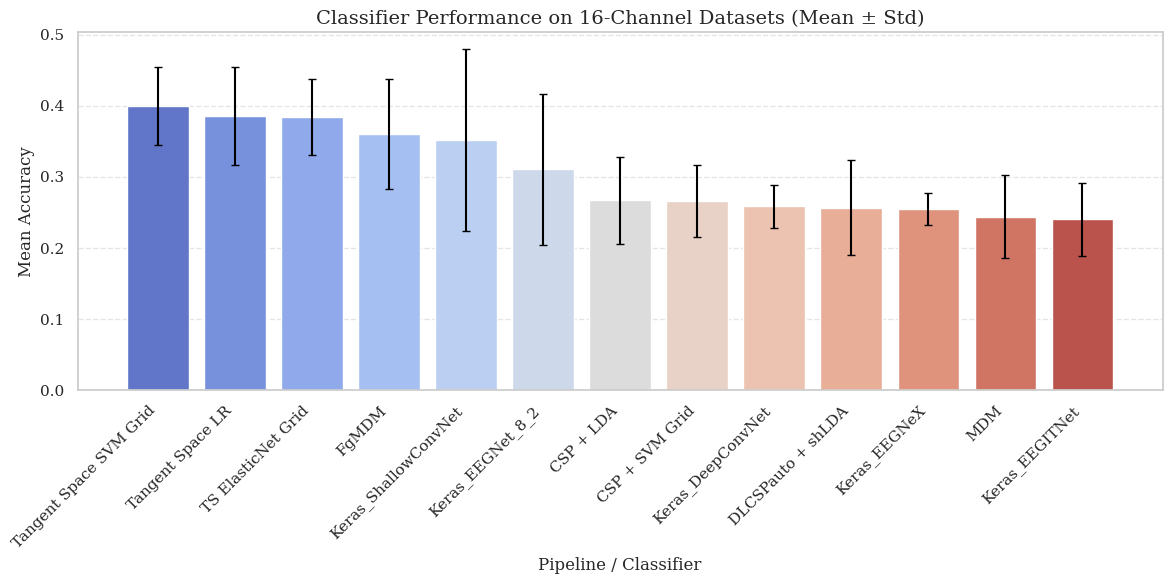


=== Most Robust Classifiers (Lowest Standard Deviation across Subjects) ===
pipeline
Keras_EEGNeX          0.022269
Keras_DeepConvNet     0.030553
Keras_EEGITNet        0.050732
CSP + SVM Grid        0.051109
TS ElasticNet Grid    0.053741
Name: score, dtype: float32


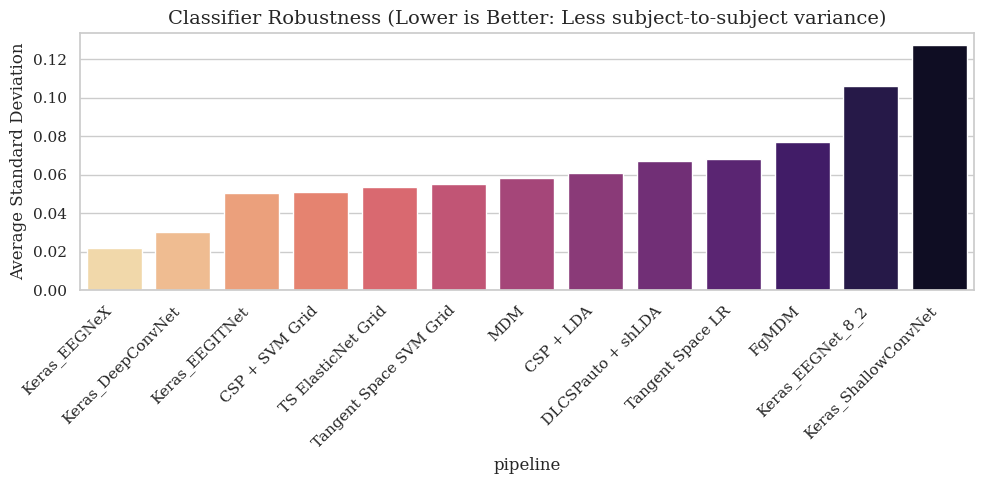

In [6]:
# 3. Best Classifiers on 16-Channel Datasets (including BrainBot)
target_datasets_mask = all_results['Channel Group'].isin(['16 Channels (Low Density)', 'BrainBot (Target)'])
low_density_results = all_results[target_datasets_mask]

# Group by Pipeline and find mean score
pipeline_performance = low_density_results.groupby('pipeline')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("=== Top 5 Classifiers on 16-Channel Datasets (Mean Accuracy) ===")
print(pipeline_performance.head(5))

# Visualize it
plt.figure(figsize=(12, 6))
sns.barplot(x=pipeline_performance.index, y='mean', data=pipeline_performance, palette='coolwarm')
plt.errorbar(x=range(len(pipeline_performance)), y=pipeline_performance['mean'], 
             yerr=pipeline_performance['std'], fmt='none', ecolor='black', capsize=3)
plt.title('Classifier Performance on 16-Channel Datasets (Mean ± Std)', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Pipeline / Classifier', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Standard Deviation across Subjects (Robustness)
# Which classifier is most consistent across subjects?
std_by_pipeline = low_density_results.groupby(['pipeline', 'dataset'])['score'].std().reset_index()
# Average STD across datasets
avg_std = std_by_pipeline.groupby('pipeline')['score'].mean().sort_values()

print("\n=== Most Robust Classifiers (Lowest Standard Deviation across Subjects) ===")
print(avg_std.head(5))

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_std.index, y=avg_std.values, palette='magma_r')
plt.title('Classifier Robustness (Lower is Better: Less subject-to-subject variance)', fontsize=14)
plt.ylabel('Average Standard Deviation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()